In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_distances
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df1 = pd.read_csv("/content/movies.csv")
df2 = pd.read_csv("/content/ratings.csv")

In [ ]:
display(df1)
display(df2)

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy
...,...,...,...
9737,193581,Black Butler: Book of the Atlantic (2017),Action|Animation|Comedy|Fantasy
9738,193583,No Game No Life: Zero (2017),Animation|Comedy|Fantasy
9739,193585,Flint (2017),Drama
9740,193587,Bungo Stray Dogs: Dead Apple (2018),Action|Animation


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931
...,...,...,...,...
100831,610,166534,4.0,1493848402
100832,610,168248,5.0,1493850091
100833,610,168250,5.0,1494273047
100834,610,168252,5.0,1493846352


In [ ]:
df_mv = df1.merge(df2, how='left', on='movieId')
display(df_mv)

,movieId,title,genres,userId,rating,timestamp
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1.0,4.0,9.649827e+08
1,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,5.0,4.0,8.474350e+08
2,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,7.0,4.5,1.106636e+09
3,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,15.0,2.5,1.510578e+09
4,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,17.0,4.5,1.305696e+09
...,...,...,...,...,...,...
100849,193581,Black Butler: Book of the Atlantic (2017),Action|Animation|Comedy|Fantasy,184.0,4.0,1.537109e+09
100850,193583,No Game No Life: Zero (2017),Animation|Comedy|Fantasy,184.0,3.5,1.537110e+09
100851,193585,Flint (2017),Drama,184.0,3.5,1.537110e+09
100852,193587,Bungo Stray Dogs: Dead Apple (2018),Action|Animation,184.0,3.5,1.537110e+09


In [ ]:
mv_matrix = df_mv.pivot_table(index='movieId', columns='userId', values='rating')

mv_matrixf = mv_matrix.fillna(0)
distances = cosine_distances(mv_matrixf)

distance_matrix = pd.DataFrame(distances, index=mv_matrixf.index, columns=mv_matrixf.index)
print(distance_matrix)

movieId    1         2         3         4         5         6         7       \
movieId                                                                         
1        0.000000  0.589438  0.703083  0.964427  0.691238  0.623684  0.722509   
2        0.589438  0.000000  0.717562  0.893585  0.712205  0.702991  0.771424   
3        0.703083  0.717562  0.000000  0.907594  0.582198  0.715743  0.597169   
4        0.964427  0.893585  0.907594  0.000000  0.811624  0.910315  0.724965   
5        0.691238  0.712205  0.582198  0.811624  0.000000  0.701031  0.525998   
...           ...       ...       ...       ...       ...       ...       ...   
193581   1.000000  1.000000  1.000000  1.000000  1.000000  1.000000  1.000000   
193583   1.000000  1.000000  1.000000  1.000000  1.000000  1.000000  1.000000   
193585   1.000000  1.000000  1.000000  1.000000  1.000000  1.000000  1.000000   
193587   1.000000  1.000000  1.000000  1.000000  1.000000  1.000000  1.000000   
193609   1.000000  1.000000 

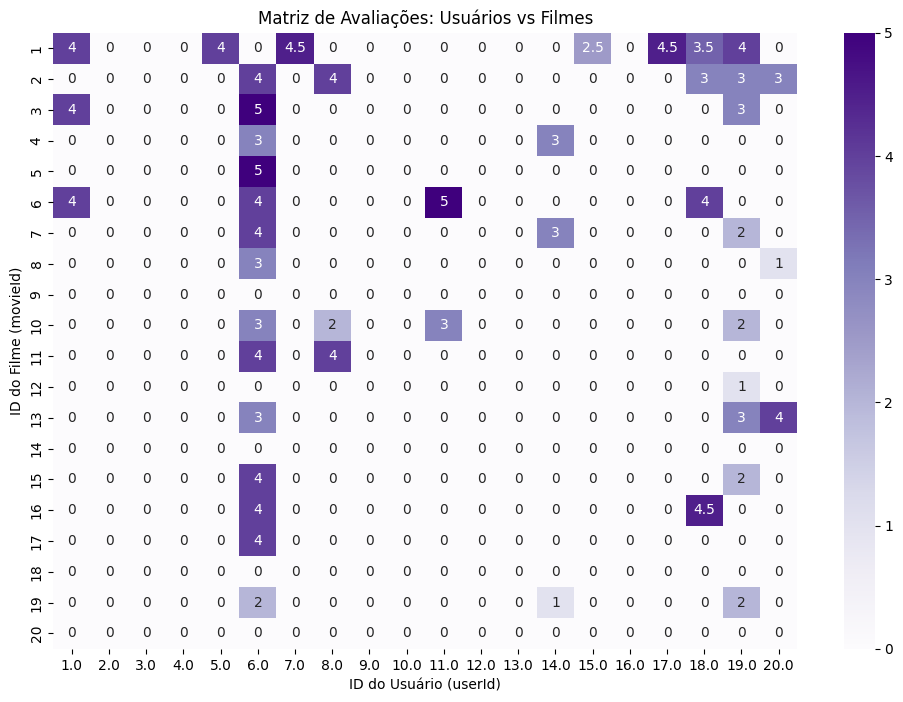

In [ ]:
subset = mv_matrixf.iloc[:20, :20]

plt.figure(figsize=(12, 8))
sns.heatmap(subset, annot=True, cmap='Purples')

plt.xlabel('ID do Usuário (userId)')
plt.ylabel('ID do Filme (movieId)')

plt.title('Matriz de Avaliações: Usuários vs Filmes')
plt.show()

In [ ]:
popularity = df_mv.groupby('title')['rating'].count().sort_values(ascending=False)

top_k = popularity.head(25)
print("Filmes mais vistos:\n")
print(top_k)

Filmes mais vistos:

title
Forrest Gump (1994)                                                               329
Shawshank Redemption, The (1994)                                                  317
Pulp Fiction (1994)                                                               307
Silence of the Lambs, The (1991)                                                  279
Matrix, The (1999)                                                                278
Star Wars: Episode IV - A New Hope (1977)                                         251
Jurassic Park (1993)                                                              238
Braveheart (1995)                                                                 237
Terminator 2: Judgment Day (1991)                                                 224
Schindler's List (1993)                                                           220
Fight Club (1999)                                                                 218
Toy Story (1995)           

In [ ]:
user_id = 1
user_ratings = df_mv[df_mv['userId'] == user_id]

rated_movie_ids = user_ratings['movieId'].unique()

unrated_movie_ids = df_mv[~df_mv['movieId'].isin(rated_movie_ids)]['movieId'].unique()

print(f"Recommendations for User ID: {user_id}")

Recommendations for User ID: 1


In [ ]:
if not user_ratings.empty:
    highest_rated_movie = user_ratings.sort_values(by='rating', ascending=False).iloc[0]
    highest_rated_movie_id = highest_rated_movie['movieId']
    highest_rated_movie_title = highest_rated_movie['title']

    print(f"\nUser {user_id} highly rated: '{highest_rated_movie_title}' (Movie ID: {highest_rated_movie_id})")

    similarity_to_highly_rated_movie = distance_matrix[highest_rated_movie_id]

    recommendations = similarity_to_highly_rated_movie[~similarity_to_highly_rated_movie.index.isin(rated_movie_ids)]

    top_recommendations = recommendations.sort_values(ascending=True).head(10)

    print("\nTop 10 Movie Recommendations for this user based on '" + highest_rated_movie_title + "':")

    recommended_movie_titles = df1[df1['movieId'].isin(top_recommendations.index)]['title']
    print(recommended_movie_titles)
else:
    print(f"User {user_id_for_recommendation} has not rated any movies in the dataset.")


User 1 highly rated: 'Seven (a.k.a. Se7en) (1995)' (Movie ID: 47)

Top 10 Movie Recommendations for this user based on 'Seven (a.k.a. Se7en) (1995)':
31              Twelve Monkeys (a.k.a. 12 Monkeys) (1995)
249                           Natural Born Killers (1994)
254     Léon: The Professional (a.k.a. The Professiona...
277                      Shawshank Redemption, The (1994)
334                                          Speed (1994)
337                                      True Lies (1994)
507                     Terminator 2: Judgment Day (1991)
613                                  Trainspotting (1996)
3141                                       Memento (2000)
4615                             Kill Bill: Vol. 1 (2003)
Name: title, dtype: object
